# Aprendizado Supervisionado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

In [2]:
from pathlib import Path
pasta_dados = Path("data")
pasta_dados.mkdir(exist_ok=True)

df_noticias = pd.read_csv(pasta_dados / "noticias.csv")
df_bow = pd.read_csv(pasta_dados/"bow.csv")
df_tfidf = pd.read_csv(pasta_dados/"tfidf.csv")

df_tfidf.head(2)

,titulo,subtitulo,descricao,temas,data,ano_mes,ano,mes,hora,turno,...,tfidf_votacao,tfidf_vulnerabilidade,tfidf_vulneraveis,tfidf_willian,tfidf_xadrez,tfidf_xxvii,tfidf_yago,tfidf_youtube,tfidf_zema,tfidf_zona
0,Minas promove capacitação de clubes de futebol...,Fale Agora será apresentado em times femininos...,Em continuidade à propagação e divulgação do P...,"['Social', 'Esportes']",2024-04-27 12:20:00-03:00,2024-04,2024,4,12,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Minas Gerais fecha primeiro bloco dos Jogos Es...,"Competição acontece em Uberlândia, no Triângul...",A delegação de Minas Gerais encerrou o primeir...,"['Social', 'Esportes']",2025-10-14 15:20:00-03:00,2025-10,2025,10,15,Tarde,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_tfidf.columns.tolist()

['titulo',
 'subtitulo',
 'descricao',
 'temas',
 'data',
 'ano_mes',
 'ano',
 'mes',
 'hora',
 'turno',
 'n_temas',
 'tamanho_texto',
 'n_palavras_titulo',
 'n_relacionadas',
 'url',
 'tfidf_abastecimento',
 'tfidf_aberta',
 'tfidf_abertas',
 'tfidf_aberto',
 'tfidf_abertura',
 'tfidf_abrangendo',
 'tfidf_abre',
 'tfidf_abriu',
 'tfidf_acaba',
 'tfidf_acao',
 'tfidf_acende',
 'tfidf_acervo',
 'tfidf_acesso',
 'tfidf_achava',
 'tfidf_acidente',
 'tfidf_acirradas',
 'tfidf_aco',
 'tfidf_acoes',
 'tfidf_acompanhar',
 'tfidf_acompanhou',
 'tfidf_acontecera',
 'tfidf_acordo',
 'tfidf_administrado',
 'tfidf_administrativa',
 'tfidf_adolescentes',
 'tfidf_adorava',
 'tfidf_aeroporto',
 'tfidf_agencia',
 'tfidf_agora',
 'tfidf_agosto',
 'tfidf_agraciados',
 'tfidf_aguardada',
 'tfidf_aguiar',
 'tfidf_ai',
 'tfidf_ainda',
 'tfidf_ajuda',
 'tfidf_ajudando',
 'tfidf_alba',
 'tfidf_alcancar',
 'tfidf_alcancaram',
 'tfidf_alcancou',
 'tfidf_alegria',
 'tfidf_alem',
 'tfidf_alencar',
 'tfidf_alguma

## montando a matriz de features X

Pegamos so as colunas que comecam com `tfidf_` para formar a matriz `X`.

In [4]:
colunas_tfidf = [c for c in df_tfidf.columns if c.startswith("tfidf_")]
X = df_tfidf[colunas_tfidf].values
print("X:", X.shape)

X: (323, 1313)


## Classificação - A notícia menciona Belo Horizonte?

Modelo construido visando identificar notícias que mencionam Belo Horizonte e, consequentemente,  avaliar se as notícias de esporte do site agência de Minas são centradas e monopolizadas na capital.

In [5]:
df_tfidf.columns

Index(['titulo', 'subtitulo', 'descricao', 'temas', 'data', 'ano_mes', 'ano',
       'mes', 'hora', 'turno',
       ...
       'tfidf_votacao', 'tfidf_vulnerabilidade', 'tfidf_vulneraveis',
       'tfidf_willian', 'tfidf_xadrez', 'tfidf_xxvii', 'tfidf_yago',
       'tfidf_youtube', 'tfidf_zema', 'tfidf_zona'],
      dtype='object', length=1328)

In [6]:
texto = df_tfidf["descricao"].fillna("") + " " + df_tfidf["titulo"].fillna("")
y_bh = texto.str.contains(r"Belo Horizonte|\bBH\b|capital", case=False, regex=True).astype(int).values

print("Distribuicao das classes:")
vc = pd.Series(y_bh).value_counts()
print(vc.rename({0: "nao menciona BH", 1: "menciona BH"}))
print(f"\n{vc[1] / len(y_bh):.1%} das noticias mencionam Belo Horizonte")

Distribuicao das classes:
nao menciona BH    303
menciona BH         20
Name: count, dtype: int64

6.2% das noticias mencionam Belo Horizonte


### separação em treino / validação / teste

In [7]:
X_tmp, X_teste_bh, y_tmp, y_teste_bh = train_test_split(
    X, y_bh, test_size=0.2, random_state=42, stratify=y_bh
)
X_treino_bh, X_calib_bh, y_treino_bh, y_calib_bh = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_bh.shape}")
print(f"calibracao: {X_calib_bh.shape}")
print(f"teste:      {X_teste_bh.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo

In [8]:
modelo_bh = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_bh.fit(X_treino_bh, y_treino_bh)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### calibração

In [9]:
probs_calib_bh = modelo_bh.predict_proba(X_calib_bh)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_bh = []
for t in limiares:
    pred = (probs_calib_bh > t).astype(int)
    f1 = f1_score(y_calib_bh, pred, zero_division=0)
    resultados_bh.append((t, f1))

df_lim_bh = pd.DataFrame(resultados_bh, columns=["limiar", "f1_calib"])
melhor_limiar_bh = df_lim_bh.loc[df_lim_bh["f1_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_bh:.2f}")
df_lim_bh

Melhor limiar pela calibracao: 0.15


,limiar,f1_calib
0,0.10,0.666667
1,0.15,0.857143
2,0.20,0.857143
3,0.25,0.857143
4,0.30,0.857143
5,0.35,0.857143
6,0.40,0.666667
7,0.45,0.400000
8,0.50,0.400000
9,0.55,0.400000


### avaliando no teste

In [10]:
probs_teste_bh = modelo_bh.predict_proba(X_teste_bh)[:, 1]
pred_teste_bh = (probs_teste_bh > melhor_limiar_bh).astype(int)

acc  = accuracy_score(y_teste_bh, pred_teste_bh)
prec = precision_score(y_teste_bh, pred_teste_bh, zero_division=0)
rec  = recall_score(y_teste_bh, pred_teste_bh, zero_division=0)
f1   = f1_score(y_teste_bh, pred_teste_bh, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_bh, pred_teste_bh, target_names=["nao menciona BH", "menciona BH"]))

Acuracia: 1.000
Precisao: 1.000
Recall:   1.000
F1:       1.000

Relatorio completo:
                 precision    recall  f1-score   support

nao menciona BH       1.00      1.00      1.00        61
    menciona BH       1.00      1.00      1.00         4

       accuracy                           1.00        65
      macro avg       1.00      1.00      1.00        65
   weighted avg       1.00      1.00      1.00        65



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
                 nao menciona BH  menciona BH
nao menciona BH               61            0
menciona BH                    0            4


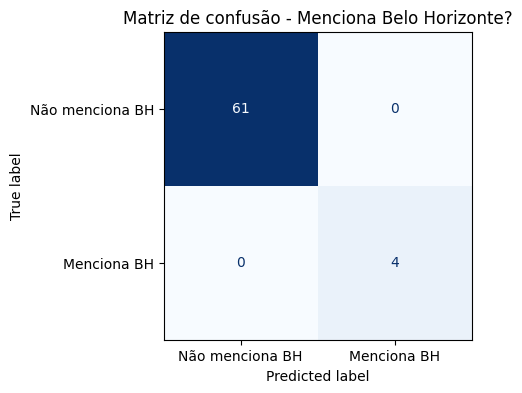

In [11]:
cm_bh = confusion_matrix(y_teste_bh, pred_teste_bh)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_bh, index=["nao menciona BH", "menciona BH"], columns=["nao menciona BH", "menciona BH"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_bh, display_labels=["Não menciona BH", "Menciona BH"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusão - Menciona Belo Horizonte?")
plt.show()

## 2) Classificação - A notícia tem a tag Social?

A coluna `temas` contem as tags associadas a cada notícia. Esse modelo visa identificar as notícias de esporte que apresentam cunho social (inclusão, programas sociais, vulnerabilidade, entre outros.

In [12]:
y_social = df_tfidf["temas"].str.contains("Social", na=False).astype(int).values

print("Distribuicao das classes:")
print(pd.Series(y_social).value_counts().rename({0: "sem Social", 1: "com Social"}))

Distribuicao das classes:
com Social    176
sem Social    147
Name: count, dtype: int64


### separação em treino / validação / teste

In [13]:
X_tmp, X_teste_soc, y_tmp, y_teste_soc = train_test_split(
    X, y_social, test_size=0.2, random_state=42, stratify=y_social
)
X_treino_soc, X_calib_soc, y_treino_soc, y_calib_soc = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_soc.shape}")
print(f"calibracao: {X_calib_soc.shape}")
print(f"teste:      {X_teste_soc.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo

In [14]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
modelo_svm.fit(X_treino_soc, y_treino_soc)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


### calibração

In [15]:
probs_calib_svm = modelo_svm.predict_proba(X_calib_soc)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_svm = []
for t in limiares:
    pred = (probs_calib_svm > t).astype(int)
    acc = accuracy_score(y_calib_soc, pred)
    resultados_svm.append((t, acc))

df_lim_svm = pd.DataFrame(resultados_svm, columns=["limiar", "acuracia_calib"])
melhor_limiar_svm = df_lim_svm.loc[df_lim_svm["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_svm:.2f}")
df_lim_svm

Melhor limiar pela calibracao: 0.55


,limiar,acuracia_calib
0,0.10,0.553846
1,0.15,0.553846
2,0.20,0.569231
3,0.25,0.569231
4,0.30,0.569231
5,0.35,0.569231
6,0.40,0.600000
7,0.45,0.584615
8,0.50,0.615385
9,0.55,0.661538


### avaliando no teste

In [16]:
probs_teste_svm = modelo_svm.predict_proba(X_teste_soc)[:, 1]
pred_teste_svm = (probs_teste_svm > melhor_limiar_svm).astype(int)

acc  = accuracy_score(y_teste_soc, pred_teste_svm)
prec = precision_score(y_teste_soc, pred_teste_svm, zero_division=0)
rec  = recall_score(y_teste_soc, pred_teste_svm, zero_division=0)
f1   = f1_score(y_teste_soc, pred_teste_svm, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_soc, pred_teste_svm, target_names=["sem Social", "com Social"]))

Acuracia: 0.662
Precisao: 0.710
Recall:   0.629
F1:       0.667

Relatorio completo:
              precision    recall  f1-score   support

  sem Social       0.62      0.70      0.66        30
  com Social       0.71      0.63      0.67        35

    accuracy                           0.66        65
   macro avg       0.66      0.66      0.66        65
weighted avg       0.67      0.66      0.66        65



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
              não é social  é social
não é social            21         9
é social                13        22


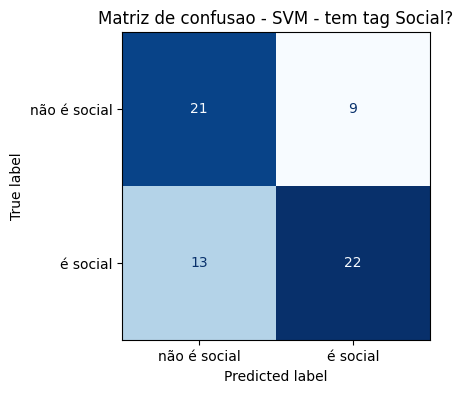

In [17]:
cm_svm = confusion_matrix(y_teste_soc, pred_teste_svm)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_svm, index=["não é social", "é social"], columns=["não é social", "é social"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_svm, display_labels=["não é social", "é social"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - SVM - tem tag Social?")
plt.show()

## É de infraestrutura?

In [18]:
y_infra = df_tfidf["temas"].str.contains("Infraestrutura", na=False).astype(int).values

print("Distribuicao das classes:")
print(pd.Series(y_infra).value_counts().rename({0: "sem infraestrutura", 1: "com infraestrutura"}))

Distribuicao das classes:
sem infraestrutura    288
com infraestrutura     35
Name: count, dtype: int64


### separação em treino / validação / teste

In [19]:
X_tmp, X_teste_infra, y_tmp, y_teste_infra = train_test_split(
    X, y_infra, test_size=0.2, random_state=42, stratify=y_infra
)
X_treino_infra, X_calib_infra, y_treino_infra, y_calib_infra = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_infra.shape}")
print(f"calibracao: {X_calib_infra.shape}")
print(f"teste:      {X_teste_infra.shape}")

treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo

In [20]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
modelo_svm.fit(X_treino_infra, y_treino_infra)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


### calibração

In [21]:
probs_calib_svm = modelo_svm.predict_proba(X_calib_infra)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_svm = []
for t in limiares:
    pred = (probs_calib_svm > t).astype(int)
    acc = accuracy_score(y_calib_infra, pred)
    resultados_svm.append((t, acc))

df_lim_svm = pd.DataFrame(resultados_svm, columns=["limiar", "acuracia_calib"])
melhor_limiar_svm = df_lim_svm.loc[df_lim_svm["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_svm:.2f}")
df_lim_svm

Melhor limiar pela calibracao: 0.15


,limiar,acuracia_calib
0,0.10,0.876923
1,0.15,0.953846
2,0.20,0.938462
3,0.25,0.923077
4,0.30,0.938462
5,0.35,0.923077
6,0.40,0.907692
7,0.45,0.907692
8,0.50,0.907692
9,0.55,0.907692


### avaliando no teste

In [22]:
probs_teste_svm = modelo_svm.predict_proba(X_teste_infra)[:, 1]
pred_teste_svm = (probs_teste_svm > melhor_limiar_svm).astype(int)

acc  = accuracy_score(y_teste_infra, pred_teste_svm)
prec = precision_score(y_teste_infra, pred_teste_svm, zero_division=0)
rec  = recall_score(y_teste_infra, pred_teste_svm, zero_division=0)
f1   = f1_score(y_teste_infra, pred_teste_svm, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}\n")

print("Relatorio completo:")
print(classification_report(y_teste_infra, pred_teste_svm, target_names=["não é de infraestrutura", "é de infraestrutura"]))

Acuracia: 0.923
Precisao: 0.667
Recall:   0.571
F1:       0.615

Relatorio completo:
                         precision    recall  f1-score   support

não é de infraestrutura       0.95      0.97      0.96        58
    é de infraestrutura       0.67      0.57      0.62         7

               accuracy                           0.92        65
              macro avg       0.81      0.77      0.79        65
           weighted avg       0.92      0.92      0.92        65



### matriz de confusão

Matriz de confusao (linhas=real, colunas=previsto):
                         não é de infraestrutura  é de infraestrutura
não é de infraestrutura                       56                    2
é de infraestrutura                            3                    4


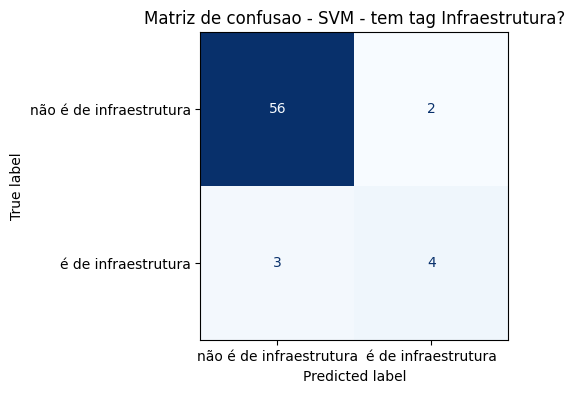

In [23]:
cm_svm = confusion_matrix(y_teste_infra, pred_teste_svm)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_svm, index=["não é de infraestrutura", "é de infraestrutura"], columns=["não é de infraestrutura", "é de infraestrutura"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_svm, display_labels=["não é de infraestrutura", "é de infraestrutura"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - SVM - tem tag Infraestrutura?")
plt.show()

## 3) Classificação - Qual política pública esportiva a notícia representa?

A partir do vocabulário do texto, podemos identificar a qual política pública esportiva uma notícia está associada?
Criamos um alvo  usando palavras-chave enriquecidas com os termos mais frequentes do TF-IDF para cada categoria:

- **esporte_escolar**: noticias ligadas ao esporte no ambiente educacional.
- **inclusao_social**: noticias com foco em transformacao social, acessibilidade e vulnerabilidade.
- **infraestrutura**: noticias sobre construcao, reforma e equipamentos esportivos.
- **alto_rendimento**: noticias sobre atletas, competicoes e rendimento esportivo.
- **outros**: noticias que nao se encaixam nas categorias anteriores.


In [24]:
def classificar_politica(texto):
    texto = str(texto).lower()
    if any(p in texto for p in [
        'escola', 'aluno', 'jogos escolares', 'estudante', 'educacao',
        'educação', 'escolar', 'ensino', 'colégio', 'colegio',
        'universitario', 'universitário', 'academico', 'acadêmico',
        'jemg', 'jerem', 'jimi'
    ]):
        return 'esporte_escolar'
    elif any(p in texto for p in [
        'inclusao', 'inclusão', 'social', 'comunidade', 'vulnerabilidade',
        'acessibilidade', 'juventude', 'cidadania', 'pcd', 'diversidade',
        'transformacao', 'transformação', 'periferia', 'assistencia',
        'assistência', 'programa social', 'projeto social', 'bolsa',
        'familiar', 'risco', 'voluntario', 'voluntário', 'acao social',
        'ação social'
    ]):
        return 'inclusao_social'
    elif any(p in texto for p in [
        'arena', 'ginasio', 'ginásio', 'obra', 'reforma', 'infraestrutura',
        'construcao', 'construção', 'estadio', 'estádio', 'quadra',
        'piscina', 'pista', 'centro esportivo', 'complexo', 'equipamento',
        'instalacao', 'instalação', 'vestiario', 'vestiário', 'academia'
    ]):
        return 'infraestrutura'
    elif any(p in texto for p in [
        'atleta', 'alto rendimento', 'competicao', 'competição',
        'treinamento', 'medalha', 'campeonato', 'torneio', 'copa',
        'olimpiada', 'olimpíada', 'paraolimpiada', 'paraolimpíada',
        'selecao', 'seleção', 'tecnico', 'técnico', 'federacao',
        'federação', 'liga', 'profissional', 'rendimento'
    ]):
        return 'alto_rendimento'
    else:
        return 'outros'

texto_politica = df_tfidf["descricao"].fillna("") + " " + df_tfidf["titulo"].fillna("")
y_politica = texto_politica.apply(classificar_politica).values

print("Distribuicao das classes:")
print(pd.Series(y_politica).value_counts())


Distribuicao das classes:
esporte_escolar    124
inclusao_social     75
alto_rendimento     55
outros              46
infraestrutura      23
Name: count, dtype: int64


### separação em treino / validação / teste


In [25]:
from sklearn.preprocessing import LabelEncoder

le_pol = LabelEncoder()
y_politica_enc = le_pol.fit_transform(y_politica)

X_tmp, X_teste_pol, y_tmp, y_teste_pol = train_test_split(
    X, y_politica_enc, test_size=0.2, random_state=42, stratify=y_politica_enc
)
X_treino_pol, X_calib_pol, y_treino_pol, y_calib_pol = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_pol.shape}")
print(f"calibracao: {X_calib_pol.shape}")
print(f"teste:      {X_teste_pol.shape}")


treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo e escolhendo o número de árvores


In [26]:
n_estimators_list = [10, 50, 100, 200, 400]
resultados_pol = []
modelos_pol = {}

for n in n_estimators_list:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_pol, y_treino_pol)
    pred_calib = modelo.predict(X_calib_pol)
    acc = accuracy_score(y_calib_pol, pred_calib)
    resultados_pol.append((n, acc))
    modelos_pol[n] = modelo

df_pol = pd.DataFrame(resultados_pol, columns=["n_estimators", "acuracia_calib"])
melhor_n_pol = int(df_pol.loc[df_pol["acuracia_calib"].idxmax(), "n_estimators"])
print(f"Melhor n_estimators pela calibracao: {melhor_n_pol}")
df_pol


Melhor n_estimators pela calibracao: 400


,n_estimators,acuracia_calib
0,10,0.646154
1,50,0.661538
2,100,0.692308
3,200,0.707692
4,400,0.723077


### avaliando no teste


In [28]:
modelo_pol = modelos_pol[melhor_n_pol]
pred_teste_pol = modelo_pol.predict(X_teste_pol)

acc = accuracy_score(y_teste_pol, pred_teste_pol)
print(f"Acuracia: {acc:.3f}")

print("Relatorio completo:")
print(classification_report(y_teste_pol, pred_teste_pol, target_names=le_pol.classes_))


Acuracia: 0.692
Relatorio completo:
                 precision    recall  f1-score   support

alto_rendimento       0.42      0.45      0.43        11
esporte_escolar       0.68      0.84      0.75        25
inclusao_social       0.92      0.73      0.81        15
 infraestrutura       1.00      0.60      0.75         5
         outros       0.71      0.56      0.62         9

       accuracy                           0.69        65
      macro avg       0.75      0.64      0.67        65
   weighted avg       0.72      0.69      0.69        65



### matriz de confusão


Matriz de confusao (linhas=real, colunas=previsto):
                 alto_rendimento  esporte_escolar  inclusao_social  \
alto_rendimento                5                5                0   
esporte_escolar                2               21                1   
inclusao_social                2                2               11   
infraestrutura                 2                0                0   
outros                         1                3                0   

                 infraestrutura  outros  
alto_rendimento               0       1  
esporte_escolar               0       1  
inclusao_social               0       0  
infraestrutura                3       0  
outros                        0       5  


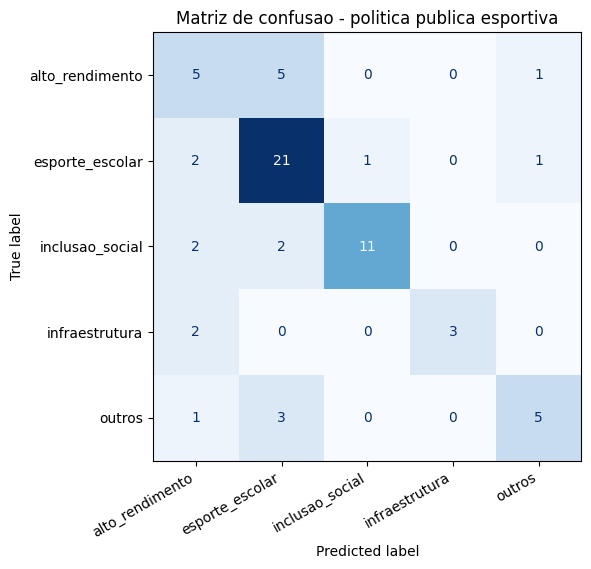

In [29]:
cm_pol = confusion_matrix(y_teste_pol, pred_teste_pol)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_pol, index=le_pol.classes_, columns=le_pol.classes_))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm_pol, display_labels=le_pol.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - politica publica esportiva")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4) Classificação - O discurso esportivo está associado à transformação social?

Queremos medir o quanto o discurso das noticias de esporte esta associado a transformacao social.
Criamos um alvo binario  que vale  quando o texto contem palavras de transformacao social e  caso contrario.


In [31]:
palavras_sociais = [
    'inclusao', 'inclusão', 'social', 'comunidade', 'acessibilidade',
    'juventude', 'cidadania', 'vulnerabilidade', 'pcd', 'diversidade',
    'transformacao', 'transformação', 'periferia', 'assistencia',
    'assistência', 'voluntario', 'voluntário', 'solidariedade',
    'empoderamento', 'equidade', 'direitos', 'oportunidade',
    'desenvolvimento humano', 'bem estar', 'bem-estar', 'qualidade de vida',
    'participacao', 'participação', 'protagonismo', 'resgate',
    'reintegracao', 'reintegração', 'cooperacao', 'cooperação'
]

texto_trans = df_tfidf["descricao"].fillna("") + " " + df_tfidf["titulo"].fillna("")
y_trans = texto_trans.apply(
    lambda t: int(any(p in str(t).lower() for p in palavras_sociais))
).values

print("Distribuicao das classes:")
vc = pd.Series(y_trans).value_counts()
print(vc.rename({0: "sem transformacao social", 1: "com transformacao social"}))
print(f"{vc[1] / len(y_trans):.1%} das noticias tem discurso de transformacao social")


Distribuicao das classes:
sem transformacao social    219
com transformacao social    104
Name: count, dtype: int64
32.2% das noticias tem discurso de transformacao social


### separação em treino / validação / teste


In [32]:
X_tmp, X_teste_tr, y_tmp, y_teste_tr = train_test_split(
    X, y_trans, test_size=0.2, random_state=42, stratify=y_trans
)
X_treino_tr, X_calib_tr, y_treino_tr, y_calib_tr = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_tr.shape}")
print(f"calibracao: {X_calib_tr.shape}")
print(f"teste:      {X_teste_tr.shape}")


treino:     (193, 1313)
calibracao: (65, 1313)
teste:      (65, 1313)


### treinando o modelo


In [33]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelo_tr = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
modelo_tr.fit(X_treino_tr, y_treino_tr)


,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


### calibração


In [34]:
probs_calib_tr = modelo_tr.predict_proba(X_calib_tr)[:, 1]

limiares = np.linspace(0.1, 0.9, 17)
resultados_tr = []
for t in limiares:
    pred = (probs_calib_tr > t).astype(int)
    acc = accuracy_score(y_calib_tr, pred)
    resultados_tr.append((t, acc))

df_lim_tr = pd.DataFrame(resultados_tr, columns=["limiar", "acuracia_calib"])
melhor_limiar_tr = df_lim_tr.loc[df_lim_tr["acuracia_calib"].idxmax(), "limiar"]
print(f"Melhor limiar pela calibracao: {melhor_limiar_tr:.2f}")
df_lim_tr


Melhor limiar pela calibracao: 0.45


,limiar,acuracia_calib
0,0.10,0.584615
1,0.15,0.707692
2,0.20,0.815385
3,0.25,0.815385
4,0.30,0.861538
5,0.35,0.892308
6,0.40,0.907692
7,0.45,0.923077
8,0.50,0.907692
9,0.55,0.907692


### avaliando no teste


In [36]:
probs_teste_tr = modelo_tr.predict_proba(X_teste_tr)[:, 1]
pred_teste_tr = (probs_teste_tr > melhor_limiar_tr).astype(int)

acc  = accuracy_score(y_teste_tr, pred_teste_tr)
prec = precision_score(y_teste_tr, pred_teste_tr, zero_division=0)
rec  = recall_score(y_teste_tr, pred_teste_tr, zero_division=0)
f1   = f1_score(y_teste_tr, pred_teste_tr, zero_division=0)

print(f"Acuracia: {acc:.3f}")
print(f"Precisao: {prec:.3f}")
print(f"Recall:   {rec:.3f}")
print(f"F1:       {f1:.3f}")

print("Relatorio completo:")
print(classification_report(y_teste_tr, pred_teste_tr, target_names=["sem transformacao social", "com transformacao social"]))


Acuracia: 0.908
Precisao: 0.941
Recall:   0.762
F1:       0.842
Relatorio completo:
                          precision    recall  f1-score   support

sem transformacao social       0.90      0.98      0.93        44
com transformacao social       0.94      0.76      0.84        21

                accuracy                           0.91        65
               macro avg       0.92      0.87      0.89        65
            weighted avg       0.91      0.91      0.90        65



### matriz de confusão


Matriz de confusao (linhas=real, colunas=previsto):
                    sem transf. social  com transf. social
sem transf. social                  43                   1
com transf. social                   5                  16


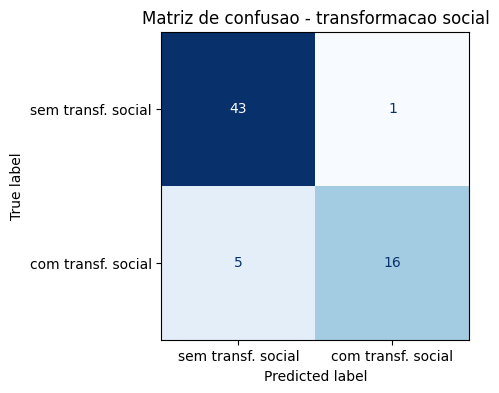

In [37]:
cm_tr = confusion_matrix(y_teste_tr, pred_teste_tr)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_tr, index=["sem transf. social", "com transf. social"], columns=["sem transf. social", "com transf. social"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm_tr, display_labels=["sem transf. social", "com transf. social"]).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - transformacao social")
plt.show()


## 5) Classificação multiclasse - Prever os temas da notícia

Queremos prever qual tema principal o portal associou a cada noticia, usando apenas o texto (TF-IDF).
Primeiro exploramos graficamente os temas mais frequentes e mais co-ocorrentes, depois treinamos um modelo multiclasse.


In [38]:
import ast

# Expandindo os temas para contar cada um individualmente
temas_series = df_tfidf["temas"].dropna()
temas_flat = []
for t in temas_series:
    try:
        itens = ast.literal_eval(t)
        temas_flat.extend(itens)
    except Exception:
        temas_flat.extend([x.strip() for x in str(t).split(",")])

freq_temas = pd.Series(temas_flat).value_counts()
print("Frequencia de cada tema:")
print(freq_temas)


Frequencia de cada tema:
Esportes                     323
Social                       176
Educação                      77
Infraestrutura                35
Governo                       33
Cultura                       22
Governador                    21
Turismo                       14
Segurança                     14
Direitos Humanos               9
Trabalho                       8
Coronavírus                    7
Brumadinho                     5
Saúde                          5
Desenvolvimento Econômico      3
Gestão                         2
Meio Ambiente                  2
Pesquisa                       1
Minas Consciente               1
Name: count, dtype: int64


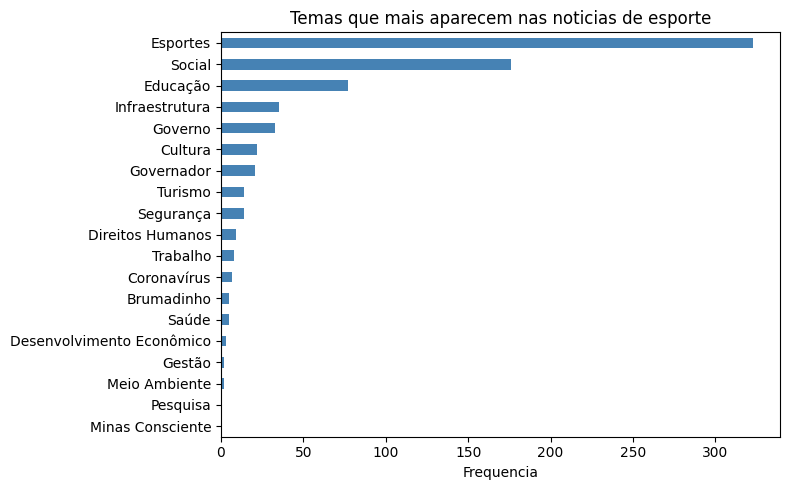

In [39]:
# Gráfico de barras — temas que mais aparecem
fig, ax = plt.subplots(figsize=(8, 5))
freq_temas.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Temas que mais aparecem nas noticias de esporte")
ax.set_xlabel("Frequencia")
plt.tight_layout()
plt.show()


In [40]:
# Co-ocorrencia entre temas
from itertools import combinations

pares = []
for t in temas_series:
    try:
        itens = ast.literal_eval(t)
    except Exception:
        itens = [x.strip() for x in str(t).split(",")]
    for par in combinations(sorted(set(itens)), 2):
        pares.append(par)

freq_pares = pd.Series(pares).value_counts().head(10)
print("Pares de temas que mais co-ocorrem:")
print(freq_pares)


Pares de temas que mais co-ocorrem:
(Esportes, Social)            176
(Educação, Esportes)           77
(Esportes, Infraestrutura)     35
(Educação, Social)             35
(Esportes, Governo)            33
(Cultura, Esportes)            22
(Esportes, Governador)         21
(Governo, Social)              16
(Governador, Governo)          15
(Esportes, Turismo)            14
Name: count, dtype: int64


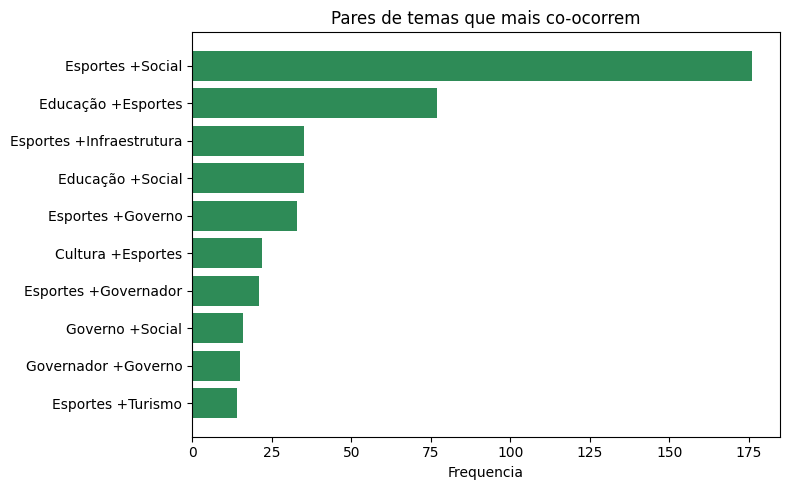

In [42]:
# Gráfico de co-ocorrência
labels = [f"{a} +{b}" for (a, b) in freq_pares.index]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(labels, freq_pares.values, color="seagreen")
ax.invert_yaxis()
ax.set_title("Pares de temas que mais co-ocorrem")
ax.set_xlabel("Frequencia")
plt.tight_layout()
plt.show()


In [43]:
# Para o modelo multiclasse, usamos o PRIMEIRO tema de cada noticia como label
def primeiro_tema(t):
    try:
        itens = ast.literal_eval(t)
        return itens[0] if itens else "Outros"
    except Exception:
        return str(t).split(",")[0].strip()

y_tema = df_tfidf["temas"].fillna("Outros").apply(primeiro_tema).values

print("Distribuicao das classes (tema principal):")
print(pd.Series(y_tema).value_counts())


Distribuicao das classes (tema principal):
Social            145
Esportes          122
Infraestrutura     26
Turismo            10
Educação            4
Saúde               4
Trabalho            4
Governo             3
Segurança           2
Gestão              1
Cultura             1
Governador          1
Name: count, dtype: int64


### separação em treino / validação / teste


In [44]:
le_tema = LabelEncoder()
y_tema_enc = le_tema.fit_transform(y_tema)

X_tmp, X_teste_tema, y_tmp, y_teste_tema = train_test_split(
    X, y_tema_enc, test_size=0.2, random_state=42, stratify=y_tema_enc
)
X_treino_tema, X_calib_tema, y_treino_tema, y_calib_tema = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

print(f"treino:     {X_treino_tema.shape}")
print(f"calibracao: {X_calib_tema.shape}")
print(f"teste:      {X_teste_tema.shape}")


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

### treinando o modelo e escolhendo o número de árvores


In [ ]:
n_estimators_list = [10, 50, 100, 200, 400]
resultados_tema = []
modelos_tema = {}

for n in n_estimators_list:
    modelo = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    modelo.fit(X_treino_tema, y_treino_tema)
    pred_calib = modelo.predict(X_calib_tema)
    acc = accuracy_score(y_calib_tema, pred_calib)
    resultados_tema.append((n, acc))
    modelos_tema[n] = modelo

df_tema = pd.DataFrame(resultados_tema, columns=["n_estimators", "acuracia_calib"])
melhor_n_tema = int(df_tema.loc[df_tema["acuracia_calib"].idxmax(), "n_estimators"])
print(f"Melhor n_estimators pela calibracao: {melhor_n_tema}")
df_tema


### avaliando no teste


In [ ]:
modelo_tema = modelos_tema[melhor_n_tema]
pred_teste_tema = modelo_tema.predict(X_teste_tema)

acc = accuracy_score(y_teste_tema, pred_teste_tema)
print(f"Acuracia: {acc:.3f}
")

print("Relatorio completo:")
print(classification_report(y_teste_tema, pred_teste_tema, target_names=le_tema.classes_))


### matriz de confusão


In [ ]:
cm_tema = confusion_matrix(y_teste_tema, pred_teste_tema)
print("Matriz de confusao (linhas=real, colunas=previsto):")
print(pd.DataFrame(cm_tema, index=le_tema.classes_, columns=le_tema.classes_))

n_classes = len(le_tema.classes_)
fig, ax = plt.subplots(figsize=(n_classes + 2, n_classes + 2))
ConfusionMatrixDisplay(cm_tema, display_labels=le_tema.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusao - tema principal da noticia")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
